# Module 04 Lab: Simulating Spiking Neurons
**ITAI 4374: Neuroscience as a Model for AI** | Houston City College | Spring 2026

---

In this lab, you will build a spiking neuron simulation from scratch. You will implement a Leaky Integrate-and-Fire (LIF) neuron, encode data as spikes, connect a small network, and run experiments.

**How to use this notebook:**
- Read each markdown cell for context and instructions
- Complete the code cells where you see `# YOUR CODE HERE`
- Answer all **Knowledge Check** and **Reflection** questions in the markdown cells provided
- Run cells in order with `Shift+Enter`

> **File naming:** Before you start, rename this notebook:  
> `L04_FirstName_LastName_ITAI4374.ipynb`  
> File → Rename (in Colab)

---
## Part A: Setup and Your First LIF Neuron

### Step 1: Import Libraries
Run this cell to set up your environment. If you see "Setup complete!" you're good to go.

In [45]:
import numpy as np
import matplotlib.pyplot as plt

print('Setup complete!')

Setup complete!


### Step 2: The LIF Equation

The Leaky Integrate-and-Fire neuron is the simplest model that captures spiking behavior. Here's the equation in discrete time:

$$V[t+1] = V[t] + dt \cdot \left( \frac{-(V[t] - V_{rest})}{\tau} + \frac{I[t]}{C} \right)$$

Where:
- **V** = membrane potential (the neuron's "voltage")
- **V_rest** = resting potential (what V returns to with no input)
- **τ (tau)** = membrane time constant (how fast voltage leaks away)
- **I** = input current
- **C** = membrane capacitance
- **dt** = time step

Think of it like a **leaky bucket**: current pours in (I), but voltage constantly leaks back toward rest. If enough current accumulates to push V above a **threshold**, the neuron fires a spike and resets.

### Step 3: Define Parameters
Run this cell to set up your neuron's parameters.

In [46]:
# ============ Simulation Parameters ============
dt = 0.001          # Time step (1 ms)
T  = 1.0            # Total simulation time (1 second)
time = np.arange(0, T, dt)  # Time array

# ============ Neuron Parameters ============
V_rest    = -70.0    # Resting potential (mV)
V_thresh  = -55.0    # Spike threshold (mV)
V_reset   = -75.0    # Reset potential after spike (mV)
tau       = 0.020    # Membrane time constant (20 ms)
C         = 1.0      # Membrane capacitance (normalized)

print(f'Simulation: {T}s with {len(time)} time steps')
print(f'Threshold: {V_thresh} mV, Rest: {V_rest} mV')

Simulation: 1.0s with 1000 time steps
Threshold: -55.0 mV, Rest: -70.0 mV


### ✅ Knowledge Check 1
Answer in the cell below:
1. Why is `V_reset` (-75 mV) set *lower* than `V_rest` (-70 mV)? What biological phenomenon does this represent?
2. The time constant `tau` is 20 ms. In plain English, what does this control?

*Your answers here:*

1. V_reset is set lower to mimic what happens after a real neuron fires: it briefly becomes more negative than resting potential (hyperpolarization). This represents the recovery period after a spike, when ion channels (especially potassium) help bring the neuron back down before it can fire again.

2. tau controls how fast the membrane potential “leaks” back toward V_rest. Smaller tau means the voltage decays faster (less integration), while larger tau means it decays more slowly (more integration of input over time).

### Step 4: Build the LIF Simulation

Now implement the core simulation loop. You need to:
1. Compute the voltage change (dV) using the LIF equation
2. Update the membrane potential
3. Check if voltage crossed the threshold → if yes, record the spike and reset

**Read the comments carefully — they tell you exactly what to do.**

In [47]:
# ============ Input Current ============
# Constant current injection: 15 nA from t=200ms to t=800ms
I_input = np.zeros(len(time))
I_input[200:800] = 800.0

# ============ Storage Arrays ============
V = np.zeros(len(time))
V[0] = V_rest
spikes = []

# ============ Simulation Loop ============
for t in range(len(time) - 1):
    # TODO 1: Compute the voltage change using the LIF equation
    dV = dt * (-(V[t] - V_rest) / tau + I_input[t] / C)

    # TODO 2: Update the membrane potential
    V[t+1] = V[t] + dV

    # TODO 3: Check if voltage crossed threshold
    if V[t+1] >= V_thresh:
        spikes.append(time[t+1])
        V[t+1] = V_reset

print(f'Neuron fired {len(spikes)} spikes')

Neuron fired 10 spikes


> **💡 Tip:** If your neuron fires 0 spikes, double-check your dV equation — make sure the signs are right. If it fires thousands, make sure you reset V to `V_reset` (not `V_rest`) after each spike.
>
> **✅ Checkpoint:** Your neuron should fire roughly 10–25 spikes with these parameters.

### Step 5: Visualize the Membrane Potential

Create a plot with two subplots:
- **Top:** Membrane potential over time (with a dashed line at the threshold)
- **Bottom:** Input current over time

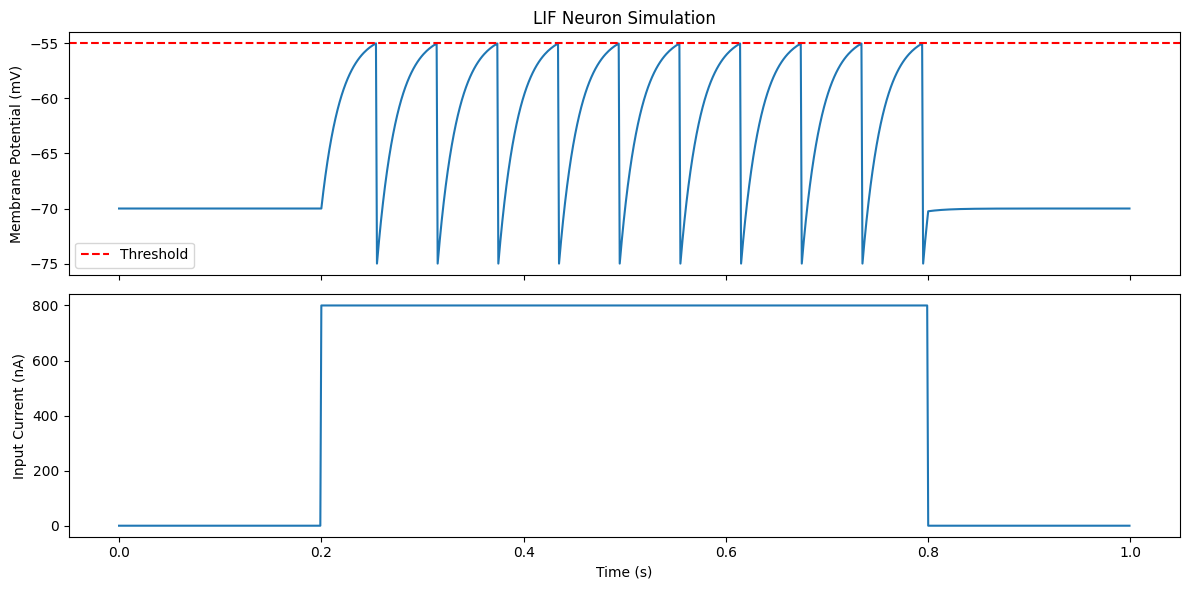

In [48]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# TODO 4: Plot membrane potential on ax1
ax1.plot(time, V)
ax1.axhline(y=V_thresh, color='r', linestyle='--', label='Threshold')

ax1.set_ylabel('Membrane Potential (mV)')
ax1.set_title('LIF Neuron Simulation')
ax1.legend()

# TODO 5: Plot input current on ax2
ax2.plot(time, I_input)

ax2.set_ylabel('Input Current (nA)')
ax2.set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

### ✅ Knowledge Check 2
Look at your plot and answer:
1. What happens to V *between* spikes — does it go straight up, or does it curve? Why?
2. What happens to V *after* the current turns off (t > 0.8s)? Explain why.

*Your answers here:*

1. It curves. The rise slows down as V gets higher because the leak term -(V - V_rest)/tau grows as V moves away from rest. So the neuron is always being pulled back toward V_rest while current pushes it up.

2. After the current turns off, V decays back toward V_rest. That happens because the input term I/C becomes ~0, leaving only the leak term, which pulls the membrane potential back to resting potential.

### 💭 Reflection 1
Look at your membrane potential trace. In the booklet, you learned that biological neurons show similar integrate-and-fire behavior. What aspects of your plot look "realistic" compared to real neurons? What looks overly simplified?

*Your reflection here:*
My membrane potential trace seems real because it adds up the input current over time, hits a threshold, makes spikes, and then resets. This is like how real neurons work, which is called "integrate-and-fire." The gradual curving rise between spikes also seems biologically possible because genuine membranes leak and don't keep increasing voltage in a straight line forever. But it's too simple since real neurons have structured action potentials (not immediate resets), refractory dynamics that depend on the timing of ion channels, and dendrites that process inputs in more complicated ways. In addition, actual spikes aren't merely a threshold event; they have a whole waveform and adaptation effects that modify how they fire over time.


---
## Part B: Encoding Data as Spikes

Real brains don't receive numbers or pixel values — they receive spikes. To feed data into a spiking neural network, we need to convert regular numbers into spike trains.

The two main strategies are:
- **Rate coding:** Higher values → more spikes per second
- **Temporal coding:** Higher values → earlier spike time

### Step 6: Rate Coding

In rate coding, at each time step we generate a random number between 0 and 1. If the random number is less than the pixel intensity, we emit a spike.

Think of it this way: a value of 0.9 has a 90% chance of spiking at each time step (lots of spikes). A value of 0.1 has only a 10% chance (few spikes).

**Complete the function below:**

In [49]:
def rate_encode(values, num_steps=100):
    """
    Convert an array of values (0 to 1) into spike trains using rate coding.

    Args:
        values: 1D numpy array with values between 0 and 1
        num_steps: number of time steps to simulate
    Returns:
        spikes: 2D array (num_steps, len(values)) where 1=spike, 0=no spike
    """
    num_neurons = len(values)
    spikes = np.zeros((num_steps, num_neurons))

    for t in range(num_steps):
        # TODO 6: Generate random numbers and compare to values
        # If random < value → spike (1), otherwise no spike (0)
        # Hint: np.random.rand(num_neurons) gives an array of random numbers
        # Hint: (random_array < values) gives True/False, use .astype(float)
        spikes[t] = (np.random.rand(num_neurons) < values).astype(float)

    return spikes

**Test your function:**

In [50]:
# Test with 5 values of increasing intensity
test_values = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
test_spikes = rate_encode(test_values, num_steps=200)

# Count spikes per neuron — higher values should produce more spikes
for i, v in enumerate(test_values):
    count = test_spikes[:, i].sum()
    print(f'Value {v:.1f} -> {count:.0f} spikes in 200 steps')

Value 0.1 -> 16 spikes in 200 steps
Value 0.3 -> 74 spikes in 200 steps
Value 0.5 -> 113 spikes in 200 steps
Value 0.7 -> 140 spikes in 200 steps
Value 0.9 -> 182 spikes in 200 steps


> **✅ Checkpoint:** Value 0.9 should have roughly ~180 spikes, value 0.1 roughly ~20. Exact numbers vary (it's random), but the trend should be clear: higher values → more spikes.

### Step 7: Temporal Coding

In temporal coding, information is in **when** a spike happens, not how many. Higher values spike earlier, lower values spike later (or not at all). Think of it as urgency: important signals arrive first.

**Complete the function below:**

In [51]:
def temporal_encode(values, num_steps=100, threshold=0.05):
    """
    Convert values (0 to 1) into spike trains using time-to-first-spike.
    Higher values spike earlier.

    Args:
        values: 1D numpy array with values between 0 and 1
        num_steps: number of time steps
        threshold: minimum value to produce a spike
    Returns:
        spikes: 2D array (num_steps, len(values))
    """
    num_neurons = len(values)
    spikes = np.zeros((num_steps, num_neurons))

    for i in range(num_neurons):
        if values[i] > threshold:
            # TODO 7: Calculate spike time
            # Higher values should spike at EARLIER time steps
            # spike_time = int((1 - values[i]) * (num_steps - 1))
            # This maps value=1.0 → time=0 and value≈0 → time≈num_steps
            spike_time = int((1 - values[i]) * (num_steps - 1))
            spikes[spike_time, i] = 1

    return spikes

### Step 8: Visualize and Compare Both Encodings

Apply both encoding methods to the same data and create **raster plots** — scatter plots where each dot represents a spike.

For a raster plot you need:
```python
times, neurons = np.where(spike_array == 1)
ax.scatter(times, neurons, s=1, color='black')
```

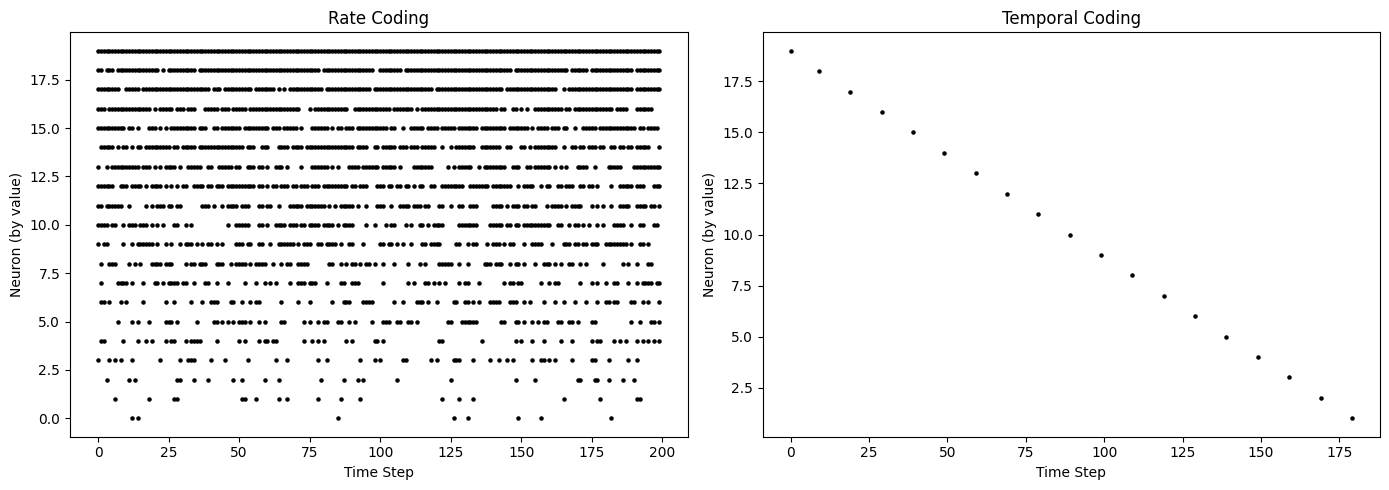

In [52]:
# Create a test signal: 20 values from 0.05 to 1.0
signal = np.linspace(0.05, 1.0, 20)

# Encode with both methods
rate_spks = rate_encode(signal, num_steps=200)
temp_spks = temporal_encode(signal, num_steps=200)

# TODO 8: Create a figure with 2 subplots side by side
# Left subplot: raster plot for rate coding
# Right subplot: raster plot for temporal coding
# Label axes: x = 'Time Step', y = 'Neuron (by value)'
# Title each subplot: 'Rate Coding' and 'Temporal Coding'
#
# YOUR CODE HERE
# Create figure with 2 subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# =========================
# Left: Rate Coding Raster
# =========================
times_rate, neurons_rate = np.where(rate_spks == 1)

ax1.scatter(times_rate, neurons_rate, s=5, color='black')
ax1.set_title('Rate Coding')
ax1.set_xlabel('Time Step')
ax1.set_ylabel('Neuron (by value)')

# ============================
# Right: Temporal Coding Raster
# ============================
times_temp, neurons_temp = np.where(temp_spks == 1)

ax2.scatter(times_temp, neurons_temp, s=5, color='black')
ax2.set_title('Temporal Coding')
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Neuron (by value)')

plt.tight_layout()
plt.show()


> **✅ Checkpoint:** Rate coding raster: scattered dots, denser at top (high-value neurons). Temporal coding raster: a diagonal line — high-value neurons spike on the left, low-value on the right.

### ✅ Knowledge Check 3
1. In rate coding, what information is lost about the original signal? What is preserved?
2. In temporal coding, why might it be *faster* for a downstream neuron to make a decision compared to rate coding?
3. Can you think of a real-world example where timing matters more than frequency? (Hint: sound localization)

*Your answers here:*

1. Rate coding preserves the general magnitude/intensity of the signal because higher values produce more spikes. But it loses precise timing information because individual spike times are random and not meaningful by themselves.

2. Because temporal coding can send information with just one early spike. A downstream neuron can "decide" as soon as it gets that spike, instead of waiting to count spikes over a longer time period like rate coding does.

3. Finding where a sound is coming from. The brain uses very small differences in the timing of when a sound reaches the left and right ears (microsecond timing differences) to figure out which way it is coming from. So, timing is more significant than spike count.

### 💭 Reflection 2
Compare your two raster plots. Which encoding would be better for a system that needs to react quickly? Which for precise measurements? The brain uses both strategies in different circuits — why do you think that is?

*Your reflection here:*
Temporal coding is ideal for a system that needs to respond rapidly since the signal is available as soon as the first spike occurs (high values spike early). Rate coding is preferable for accurate measurements because counting spikes over time helps smooth out random noise and give a more reliable picture of intensity. The brain probably utilizes both because some circuits value speed (like reflexes or quick sensory detection) more than others value precision and stable estimation (like sustained perception and graded intensity). The nervous system can be flexible depending on the task when both techniques are used.


---
## Part C: Connect a Mini Spiking Network

A single neuron is interesting, but brains are **networks**. Now you will connect multiple LIF neurons with synaptic weights.

The idea: when neuron A fires a spike, it sends current to neuron B. The amount depends on the **synaptic weight** between them.
- **Positive weight** = excitatory (helps B fire)
- **Negative weight** = inhibitory (prevents B from firing)

### Network Architecture
We'll build a 5-neuron network:
- Neurons 0, 1: **Input** (receive external current)
- Neurons 2, 3: **Hidden** (receive input from 0 and 1)
- Neuron 4: **Output** (receives input from 2 and 3)

In [53]:
# Network parameters
N = 5  # Number of neurons
T_net = 0.5
time_net = np.arange(0, T_net, dt)
steps = len(time_net)

# Weight matrix: weights[i, j] = connection from neuron i to neuron j
weights = np.zeros((N, N))
weights[0, 2] = 12.0   # Neuron 0 → 2 (excitatory)
weights[1, 3] = 12.0   # Neuron 1 → 3 (excitatory)
weights[2, 4] = 10.0   # Neuron 2 → 4 (excitatory)
weights[3, 4] = 10.0   # Neuron 3 → 4 (excitatory)

# External input: only to neurons 0 and 1
I_ext = np.zeros((steps, N))
I_ext[100:400, 0] = 18.0   # Neuron 0 gets current
I_ext[150:350, 1] = 18.0   # Neuron 1 gets current (slightly offset)

# Storage
V_net = np.full((steps, N), V_rest)
spike_log = [[] for _ in range(N)]  # Spike times per neuron
just_spiked = np.zeros(N, dtype=bool)  # Track spikes at current step

# ============ Simulation Loop ============
prev_spiked = np.zeros(N, dtype=bool)

for t in range(steps - 1):
    just_spiked[:] = False

    for n in range(N):
        # TODO 9: Total current = external + synaptic
        I_total = I_ext[t, n]
        I_total += np.sum(weights[prev_spiked, n])

        # TODO 10: LIF update
        dV = dt * (-(V_net[t, n] - V_rest) / tau + I_total / C)
        V_net[t+1, n] = V_net[t, n] + dV

        # TODO 11: Spike check
        if V_net[t+1, n] >= V_thresh:
            spike_log[n].append(time_net[t+1])
            V_net[t+1, n] = V_reset
            just_spiked[n] = True

    prev_spiked[:] = just_spiked

> **💡 Tip:** For synaptic input, one approach: before the neuron loop at each time step, check which neurons spiked at step `t-1` by seeing if `V_net[t-1, j]` was recently reset (i.e., close to `V_reset`). Or keep a separate `prev_spiked` array.
>
> **✅ Checkpoint:** Input neurons (0, 1) fire the most. Hidden (2, 3) fire next. Output (4) fires last and fewest. If neuron 4 has 0 spikes, try increasing weights slightly.

### Step 10: Visualize Network Activity

Create a raster plot for all 5 neurons, plus a subplot showing the output neuron's membrane potential.

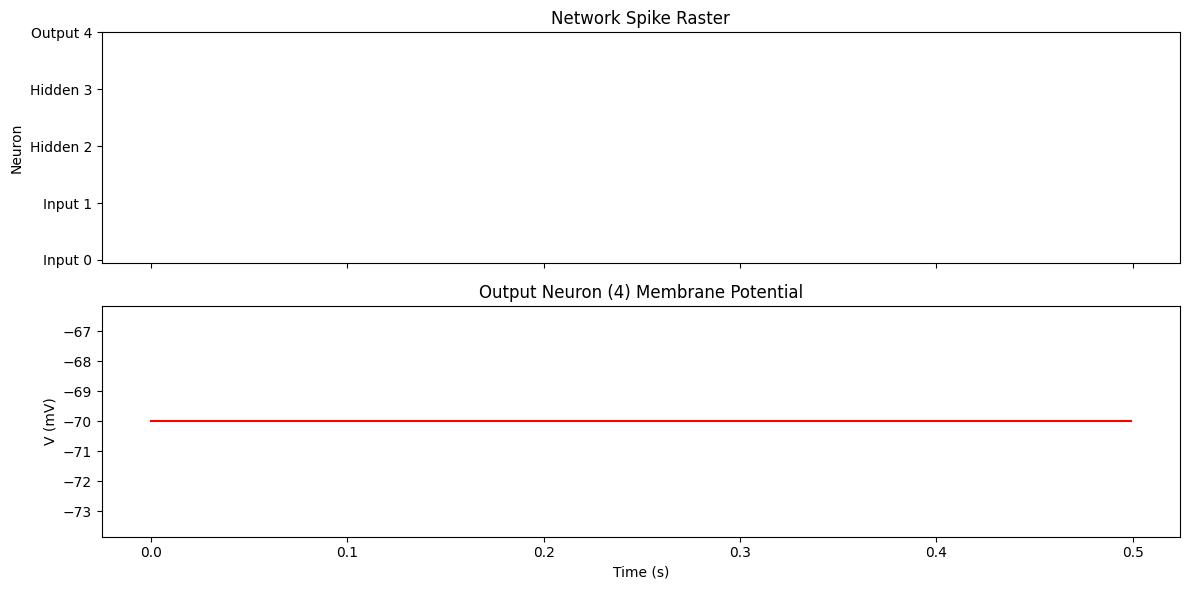

In [54]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# TODO 12: Raster plot of all neurons
# For each neuron n, plot its spike times as dots at y = n
# Use different colors: blue for input (0,1), green for hidden (2,3), red for output (4)
# Hint: ax1.scatter(spike_log[n], [n]*len(spike_log[n]), s=10, color='blue')
# YOUR CODE HERE
# TODO 12: Raster plot of all neurons
for n in range(N):
    if n in [0, 1]:
        color = 'blue'      # Input neurons
    elif n in [2, 3]:
        color = 'green'     # Hidden neurons
    else:
        color = 'red'       # Output neuron

    ax1.scatter(spike_log[n], [n] * len(spike_log[n]), s=20, color=color)
ax1.set_ylabel('Neuron')
ax1.set_title('Network Spike Raster')
ax1.set_yticks(range(N))
ax1.set_yticklabels(['Input 0', 'Input 1', 'Hidden 2', 'Hidden 3', 'Output 4'])

# TODO 13: Plot output neuron (4) membrane potential
# YOUR CODE HERE
# TODO 13: Plot output neuron (4) membrane potential
ax2.plot(time_net, V_net[:, 4], color='red')
ax2.set_ylabel('V (mV)')
ax2.set_xlabel('Time (s)')
ax2.set_title('Output Neuron (4) Membrane Potential')

plt.tight_layout()
plt.show()

### ✅ Knowledge Check 4
1. Does the output neuron fire at the same rate as the input neurons? Why or why not?
2. What role do the synaptic weights play? What would happen if you doubled them? Halved them?
3. In the brain, not all connections are excitatory. What might happen if you made `weights[3, 4]` negative (inhibitory)?

*Your answers here:*

1. No. The output neuron depends on spikes from neurons 2 and 3, so it only fires when enough upstream activity arrives through synaptic weights. Input neurons receive direct external current, so they fire more often.

2. Weights determine how much spikes from one neuron affect the input current of another neuron. If you double the weights, downstream neurons (particularly the output) will fire more and sooner. If you cut them in half, downstream neurons may not fire at all or may fire less because they won't achieve the threshold.

3. Neuron 3 would stop neuron 4 from firing by taking away current every time neuron 3 spikes. That would slow down neuron 4's firing rate, maybe even stop it from firing altogether if inhibition is stronger.

---
## Part D: Experiments

Science is about changing things and observing what happens. **Run at least 3** of the experiments below.

For each experiment:
1. What parameter did you change, and to what values?
2. What did you *expect* to happen?
3. What *actually* happened? (Include the plot.)
4. Why does this make sense given the LIF equation?

> ⚠️ **Create new code cells for experiments. Do NOT overwrite your working code above.**

### Experiment Options (pick at least 3)

**Experiment 1: Threshold Sensitivity** — Change `V_thresh` from -55 to -50, then -60. How does firing rate change?

**Experiment 2: Time Constant Effects** — Change `tau` to 0.010, then 0.050. How does the membrane potential shape change between spikes?

**Experiment 3: Varying Input** — Use a ramp current: `I_input = np.linspace(0, 25, len(time))`. How does the firing pattern change over time?

**Experiment 4: Noisy Input** — Add noise: `I_noisy = 15.0 + np.random.randn(len(time)) * 5.0`. Is the spike pattern regular or irregular?

**Experiment 5: Network Inhibition** — Set `weights[3, 4] = -8.0`. How does the output neuron change?

**Experiment 6: f–I Curve** — Sweep input current from 0 to 30. For each, count spikes. Plot current vs spike count.

### Experiment 1: Threshold Sensitivity:
**Parameter changed: V_thresh = -50, -55, -60**  
**Expected result: Higher threshold (-50) should reduce firing; lower threshold (-60) should increase firing.**  

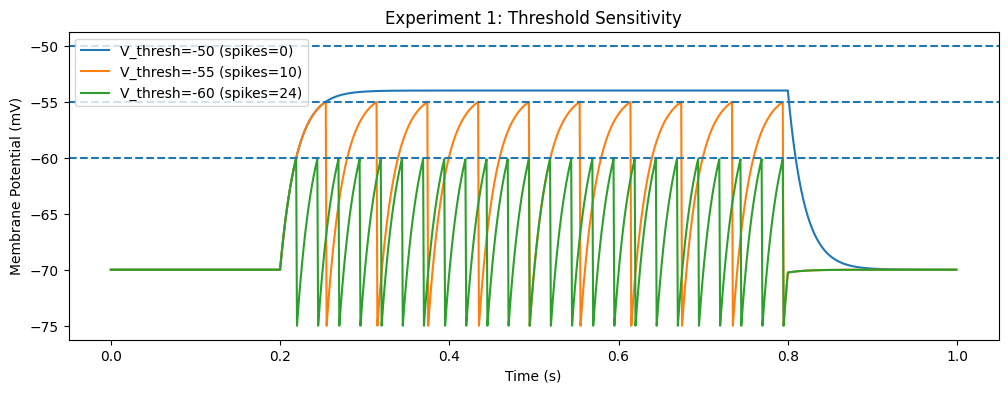

Spikes (-50): 0
Spikes (-55): 10
Spikes (-60): 24


In [55]:
# Experiment code here
def run_single_lif(V_thresh_test=-55.0):
    V_local = np.zeros(len(time))
    V_local[0] = V_rest
    spikes_local = []

    for t in range(len(time) - 1):
        dV = dt * (-(V_local[t] - V_rest) / tau + I_input[t] / C)
        V_local[t+1] = V_local[t] + dV
        if V_local[t+1] >= V_thresh_test:
            spikes_local.append(time[t+1])
            V_local[t+1] = V_reset

    return V_local, spikes_local

V50, s50 = run_single_lif(-50.0)
V55, s55 = run_single_lif(-55.0)
V60, s60 = run_single_lif(-60.0)

plt.figure(figsize=(12,4))
plt.plot(time, V50, label=f"V_thresh=-50 (spikes={len(s50)})")
plt.plot(time, V55, label=f"V_thresh=-55 (spikes={len(s55)})")
plt.plot(time, V60, label=f"V_thresh=-60 (spikes={len(s60)})")
plt.axhline(-50, linestyle="--")
plt.axhline(-55, linestyle="--")
plt.axhline(-60, linestyle="--")
plt.title("Experiment 1: Threshold Sensitivity")
plt.xlabel("Time (s)")
plt.ylabel("Membrane Potential (mV)")
plt.legend()
plt.show()

print("Spikes (-50):", len(s50))
print("Spikes (-55):", len(s55))
print("Spikes (-60):", len(s60))

**What happened:** When the threshold was raised to -50 mV, the neuron fired fewer spikes. When the threshold was lowered to -60 mV, the neuron fired more spikes and fired earlier during current injection.  
**Why it makes sense:** A lower threshold means that less integrated voltage is needed to start a spike, which makes the neuron fire more easily. A greater threshold means that more current needs to build up to achieve it, which slows down the firing rate.

### Experiment 2: Time Constant Effects
**Parameter changed:** tau = 0.010, 0.020, 0.050

**Expected result:** Smaller tau should leak faster and make V rise less smoothly; larger tau should integrate longer and produce smoother curves (often more spikes if input is sustained).

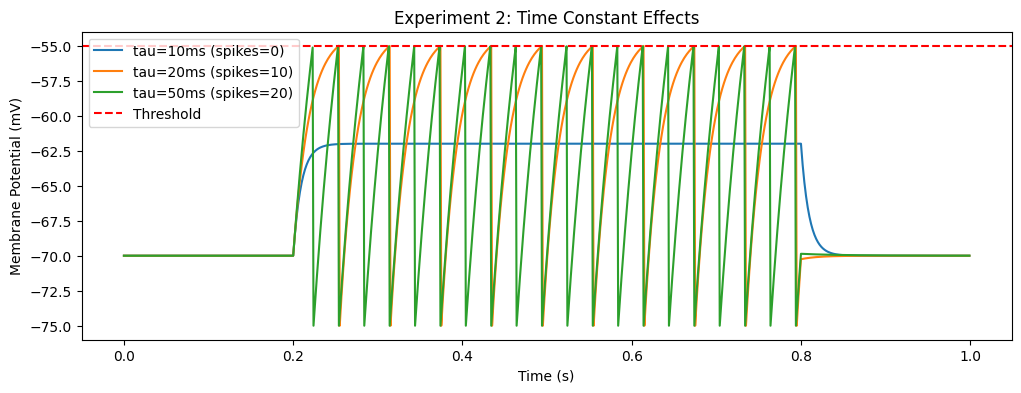

Spikes (10ms): 0
Spikes (20ms): 10
Spikes (50ms): 20


In [56]:
# Experiment code here
def run_lif_with_tau(tau_test=0.020):
    V_local = np.zeros(len(time))
    V_local[0] = V_rest
    spikes_local = []

    for t in range(len(time) - 1):
        dV = dt * (-(V_local[t] - V_rest) / tau_test + I_input[t] / C)
        V_local[t+1] = V_local[t] + dV
        if V_local[t+1] >= V_thresh:
            spikes_local.append(time[t+1])
            V_local[t+1] = V_reset

    return V_local, spikes_local

V10, s10 = run_lif_with_tau(0.010)
V20, s20 = run_lif_with_tau(0.020)
V50, s50 = run_lif_with_tau(0.050)

plt.figure(figsize=(12,4))
plt.plot(time, V10, label=f"tau=10ms (spikes={len(s10)})")
plt.plot(time, V20, label=f"tau=20ms (spikes={len(s20)})")
plt.plot(time, V50, label=f"tau=50ms (spikes={len(s50)})")
plt.axhline(V_thresh, color="r", linestyle="--", label="Threshold")
plt.title("Experiment 2: Time Constant Effects")
plt.xlabel("Time (s)")
plt.ylabel("Membrane Potential (mV)")
plt.legend()
plt.show()

print("Spikes (10ms):", len(s10))
print("Spikes (20ms):", len(s20))
print("Spikes (50ms):", len(s50))

**What happened:**  With tau = 10 ms, the voltage leaked back faster and the curve between spikes was steeper and “tighter.” With tau = 50 ms, the membrane potential changed more slowly and integrated input over a longer window, producing smoother ramps and typically more sustained firing during the injection window.

**Why it makes sense:** Tau makes the leak term bigger. A smaller τ makes the leak stronger (rapid decay), which makes it harder to build up electricity. A bigger tau lowers the leak, which means the cell can retain voltage longer and use current more effectively.

### Experiment 4: Noisy Input
**Parameter changed:** Noisy current I_noisy = 15 + N(0,5)

**Expected result:** Spike timing becomes irregular; spikes may shift earlier/later compared to constant current.

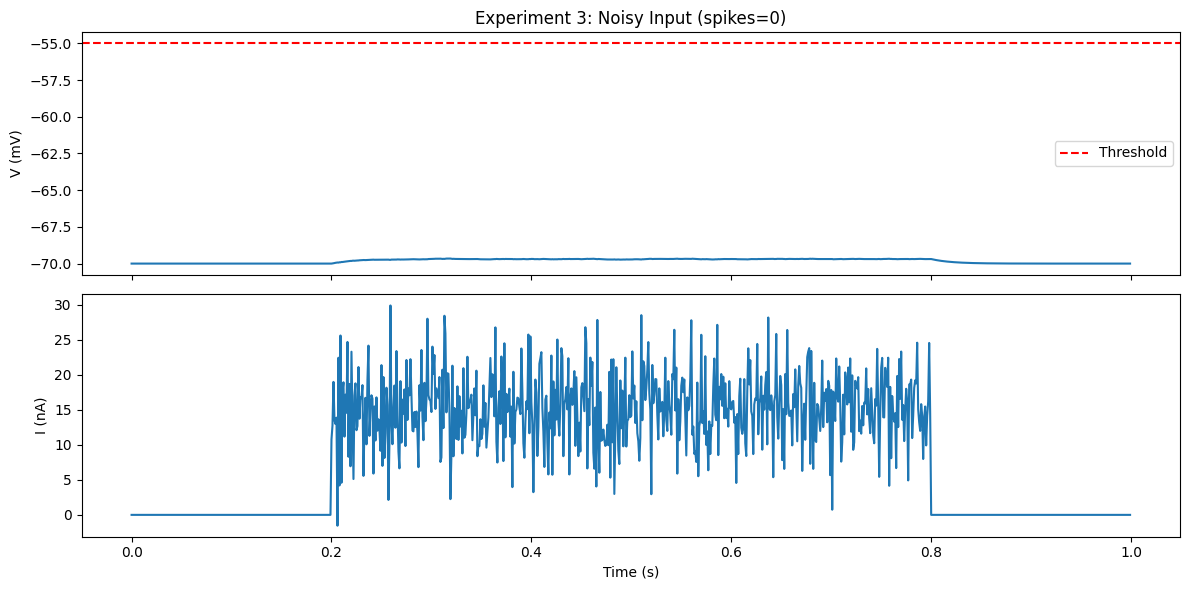

Total spikes with noise: 0


In [57]:
# Experiment code here
I_noisy = np.zeros(len(time))
I_noisy[200:800] = 15.0 + np.random.randn(600) * 5.0  # noise only during injection

Vn = np.zeros(len(time))
Vn[0] = V_rest
spikes_n = []

for t in range(len(time) - 1):
    dV = dt * (-(Vn[t] - V_rest) / tau + I_noisy[t] / C)
    Vn[t+1] = Vn[t] + dV
    if Vn[t+1] >= V_thresh:
        spikes_n.append(time[t+1])
        Vn[t+1] = V_reset

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,6), sharex=True)
ax1.plot(time, Vn)
ax1.axhline(V_thresh, color="r", linestyle="--", label="Threshold")
ax1.set_title(f"Experiment 3: Noisy Input (spikes={len(spikes_n)})")
ax1.set_ylabel("V (mV)")
ax1.legend()

ax2.plot(time, I_noisy)
ax2.set_ylabel("I (nA)")
ax2.set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

print("Total spikes with noise:", len(spikes_n))

**What happened:** The timing of the spikes became less regular. Some spikes happened earlier (when noise increased current), whereas some were late or missed (when noise decreased current). The pattern was far less regular than the steady current injection.

**Why it makes sense:** Noise changes the input term I/C at each time step, so the voltage integrates a fluctuating signal. Random increases push V to threshold sooner; random decreases slow the rise.

---
## Part E: Final Reflection

Answer each question thoughtfully. These connect your hands-on experience to the bigger picture from the booklet.

### 💭 Reflection 3
How does changing the membrane time constant (τ) affect firing behavior? What biological property does this represent? (Think about different types of neurons in the brain.)

*Your reflection here:*
When you modify τ, it changes how long the neuron "remembers" what it got. A bigger τ signifies a slower leak, which means that the neuron integrates current over a longer period of time and is more likely to keep firing while the input is steady. A smaller τ suggests that the neuron releases charge quickly, therefore it needs stronger or more steady input to attain threshold. Biologically, τ is linked to the resistance and capacitance of membranes and the characteristics of ion channels. This means that different types of neurons can combine messages over varying periods of time.


### 💭 Reflection 4
Compare your rate coding and temporal coding results. Which encoding preserved more information about the original signal? Why might the brain use both strategies in different circuits?

*Your reflection here:*
Rate coding keeps the overall intensity because higher values make more spikes over time. However, it loses specific timing information and needs a time range to guess the magnitude. Temporal coding keeps timing (high values spike early) and can send information rapidly, but it might not show sustained intensity as well. The brain probably uses both because some circuits need quick judgments (timing-based) and others need stable averaging to get accurate magnitude estimations (rate-based).


### 💭 Reflection 5
In your mini SNN, what happened when spikes propagated through layers? How does this relate to how information flows through real neural circuits?

*Your reflection here:*
In the small SNN, spikes traveled from the input neurons to the hidden neurons and then to the output neuron. The output neuron didn't fire as often because it needed spikes and synaptic weights from upstream neurons to build up enough current to cross the threshold. This is similar to genuine brain circuits, where information moves through layers and only particular patterns of activity in the upstream layer cause firing in the downstream layer.


### 💭 Reflection 6
The LIF model is a simplification. What does it capture well about real neurons? What important biological features does it miss? (Think: dendrites, neurotransmitters, morphology, adaptation.)

*Your reflection here:*
The LIF model includes the main parts of spiking, like integration, leaking back to rest, firing depending on a threshold, and resetting. It overlooks a lot of biological subtleties, like dendritic computation, synaptic time dynamics (EPSPs/IPSPs enduring over time), neurotransmitter effects, neuron morphology, spike form, adaptability, and bursting behavior. Real neurons are much more complex, and their "weights" aren't merely jumps in current.


### 💭 Reflection 7
After building these simulations, what is one thing about biological neural computation that surprised you or changed how you think about artificial intelligence?

*Your reflection here:*
What amazed me the most was how much behavior comes from a basic equation. For example, merely leak + input + threshold can make firing patterns and network propagation that look real. It changed the way I thought about AI since biological processing depends on time, spikes, and dynamics, not just continuous activations. It helped me understand why spiking networks can work well and why timing can be a type of information.


---
## 🎉 You're Done!

**Before submitting, check:**
- [ ] All code cells run without errors and outputs are visible
- [ ] All Knowledge Check questions are answered
- [ ] All Reflection prompts are answered
- [ ] At least 3 experiments completed with observations
- [ ] Notebook is named: `L04_FirstName_LastName_ITAI4374.ipynb`

**Submit:** Download this notebook (File → Download → Download .ipynb) and upload to Canvas.